In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.extractors import read_neuralynx, read_openephys
import spikeinterface.full as si
import spikeinterface.preprocessing as sipp
import probeinterface as pi
from probeinterface.plotting import plot_probe
import pandas as pd
from pathlib import Path, PurePath
import os
from typing import List
import mat73
import tempfile

In [9]:
# For Rafa
# data_path = Path("/home/born-animal/Desktop/data/")
data_path = Path("/gpfs01/born/animal/Ephys_Sleep/04_Data/01-Raw_data/Recordings/")
date = "2026-03-23_08-50-17"
full_path = Path(data_path, date, "Record Node 106")
assert full_path.exists()
save_path = Path("/gpfs01/born/animal/DanielG/playground/", date, "metadata")
if not save_path.exists():
    save_path.mkdir(parents=True)

In [9]:
# data_path = Path("/home/born-animal/Desktop/data/")
data_path = Path("/gpfs01/born/animal/Hypothalamic_Sleep/data/raw/")
animal = "HYDO02"
date = "2024-07-22_10-47-00"
full_path = Path(data_path, animal, date)
assert full_path.exists()
save_path = Path(
    "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/", animal, date, "metadata"
)
if not save_path.exists():
    save_path.mkdir(parents=True)

In [3]:
def get_corr_device_channel_indices(rec, probe):
    contact_ids = probe.contact_ids
    ch_ids = rec.get_channel_ids()
    dev_ch_inds = np.array(
        [np.where(ch_ids == str(int(id) - 1))[0][0] for id in contact_ids]
    )
    return dev_ch_inds

In [6]:
animal_dict = {
    "HYDO01": {
        "probe": {
            "probe_name": "A1x32-Poly3-10mm-50-177",
            "manufacturer": "neuronexus",
            "dev_ch_inds": np.asarray(
                [
                    0,
                    24,
                    25,
                    26,
                    27,
                    28,
                    29,
                    1,
                    2,
                    3,
                    4,
                    5,
                    6,
                    7,
                    8,
                    9,
                    10,
                    11,
                    12,
                    13,
                    14,
                    15,
                    16,
                    17,
                    18,
                    19,
                    20,
                    21,
                    22,
                    23,
                ]
            ),
            "bad_chs": [10, 27],
        },
    },
    "HYDO02": {
        "probe": {
            "probe_name": "A1x32-Poly3-10mm-50-177",
            "manufacturer": "neuronexus",
            "dev_ch_inds": np.asarray(
                [
                    0,
                    24,
                    25,
                    26,
                    27,
                    28,
                    29,
                    1,
                    2,
                    3,
                    4,
                    5,
                    6,
                    7,
                    8,
                    9,
                    10,
                    11,
                    12,
                    13,
                    14,
                    15,
                    16,
                    17,
                    18,
                    19,
                    20,
                    21,
                    22,
                    23,
                ]
            ),
            # "bad_chs": [10, 27],
        },
    },
    "HYDO03": {
        "probe": {
            "probe_name": "A1x32-Poly2-10mm-50s-177-CM32",
            "manufacturer": "neuronexus",
            "dev_ch_inds": np.asarray(
                [
                    15,
                    16,
                    14,
                    17,
                    13,
                    18,
                    12,
                    19,
                    11,
                    20,
                    10,
                    21,
                    0,
                    31,
                    1,
                    30,
                    2,
                    29,
                    3,
                    28,
                    4,
                    27,
                    5,
                    26,
                    6,
                    25,
                    7,
                    24,
                    8,
                    23,
                    9,
                    22,
                ]
            ),
        },
    },
    "HYDO04": {
        "probe": {
            "probe_name": "A1x32-Poly2-10mm-50s-177-CM32",
            "manufacturer": "neuronexus",
            "dev_ch_inds": np.asarray(
                [
                    15,
                    16,
                    14,
                    17,
                    13,
                    18,
                    12,
                    19,
                    11,
                    20,
                    10,
                    21,
                    0,
                    31,
                    1,
                    30,
                    2,
                    29,
                    3,
                    28,
                    4,
                    27,
                    5,
                    26,
                    6,
                    25,
                    7,
                    24,
                    8,
                    23,
                    9,
                    22,
                ]
            ),
        },
    },
}
probe_path = Path("/home/born-animal/Desktop/data/probes/")
probe_file = list(probe_path.glob(f"*{animal}*.json"))
if len(probe_file) > 1:
    raise ValueError(f"Multiple probe files found: {probe_file}")
probe = pi.read_probeinterface(probe_file[0]).probes[0]
if probe.device_channel_indices is None:
    print("Setting device channel indices")
    probe.set_device_channel_indices(animal_dict[animal]["probe"]["dev_ch_inds"])

fig, ax = plt.subplots(figsize=(5, 12))
plot_probe(probe, with_contact_id=True, with_device_index=True, ax=ax)

IndexError: list index out of range

In [13]:
read_openephys?

Signature: read_openephys(folder_path, **kwargs)
Docstring:
Read Open Ephys folder (in "binary" or "open ephys legacy" format).

Parameters
----------
folder_path : str or Path
    Path to openephys folder
experiment_name : str, default: None
    Name of the experiment to load (e.g., "experiment1", "experiment2").
    For open ephys binary format only. Cannot be used together with block_index.
stream_id : str, default: None
    If there are several streams, specify the stream id you want to load
stream_name : str, default: None
    If there are several streams, specify the stream name you want to load
block_index : int, default: None
    Alternative way to specify which experiment to load using a zero-based index.
    If there are several blocks (experiments), specify the block index you want to load.
    Cannot be used together with experiment_name.
all_annotations : bool, default: False
    Load exhaustively all annotation from neo
load_sync_channel : bool, default: False
    **DEPRE

In [10]:
tmp = read_openephys(full_path)

ValueError: invalid literal for int() with base 10: '1-UX1'

In [12]:
debug

> /gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/neo/rawio/openephysrawio.py(655)explore_folder()
    653                 processor_id, ch_name = s[0], s[2]
    654                 chan_type = re.split(r"(\d+)", s[2])[0]
--> 655             chan_id = int(ch_name.replace(chan_type, ""))
    656             if chan_type in chan_ids_by_type.keys():
    657                 chan_ids_by_type[chan_type].append(chan_id)

['113', 'acquisition-board-A', 'A1-AUX1']
*** NameError: name 'chan_id' is not defined
'1-UX1'


In [6]:
def load_rec(
    recording_path,
    probe=None,
    concatenate=True,
    channels=None,
    ret_lfp=False,
    ret_eeg=False,
    eeg_chs=["37", "39"],
    **kwargs,
):
    # recording = read_openephys(recording_path, **kwargs)
    recording = read_neuralynx(recording_path, **kwargs)
    if recording.get_num_segments() > 1:
        if concatenate:
            timestamps = []
            for seg in recording._recording_segments:
                timestamps.extend(seg.get_times())
            concat_recording = si.ConcatenateSegmentRecording([recording])
            concat_recording.set_times(np.array(timestamps))
            recording = concat_recording
    if ret_lfp:
        chs = recording.get_channel_ids()
        lfp_chs = [ch for ch in chs if int(ch) < 32]
        recording = recording.channel_slice(channel_ids=lfp_chs)
    if ret_eeg:
        if eeg_chs is None:
            chs = recording.get_channel_ids()
            eeg_chs = [ch for ch in chs if int(ch) >= 32]
            recording = recording.select_channels(channel_ids=eeg_chs)
        else:
            recording = recording.select_channels(channel_ids=eeg_chs)
    if probe is not None:
        dev_ch_inds = get_corr_device_channel_indices(recording, probe)
        probe.set_device_channel_indices(dev_ch_inds)
        recording.set_probe(probe=probe, in_place=True)
        # recording.set_channel_groups(
        #     np.concatenate([np.zeros(16, dtype=int), np.ones(16, dtype=int)])
        # )
    if channels:
        if channels == "all":
            recording = recording
        elif isinstance(channels, List):
            if any(channel not in recording.get_channel_ids() for channel in channels):
                raise ValueError(f">= 1 channel of {channels} not found in recording.")
            recording = recording.select_channels(channel_ids=channels)
    return recording

In [10]:
tmp_eeg = load_rec(
    recording_path=full_path,
    probe=None,
    ret_eeg=True,
    ret_lfp=False,
    eeg_chs=["37", "39"],
    **{"stream_id": "0"},
)

In [21]:
def load_rec_from_disk(param_id, region):
    rec_path = Path(save_path.parent, "rec", region)

    if not rec_path.exists():
        print(f"Recording path {rec_path} does not exist.")
        return None
    exact_match = Path(rec_path, param_id)
    if not exact_match.exists():
        potential_rec_dirs = list(rec_path.glob(param_id))
        if len(potential_rec_dirs) != 1:
            print(
                f"param_id: {param_id} is not specific enough."
                f"{potential_rec_dirs} found\nreturning None"
            )
            return None
        rec_path = potential_rec_dirs[0]
    else:
        rec_path = exact_match
    print(f"loading recording from disk.. {rec_path.name}")
    recording = si.load(rec_path)
    return recording

In [69]:
tmp_spi_rec = load_rec_from_disk(param_id="none_1da2_spindle_a0a3", region="ctx")
tmp_so_rec = load_rec_from_disk(param_id="none_1da2_so_3c1a", region="ctx")

loading recording from disk.. none_1da2_spindle_a0a3
loading recording from disk.. none_1da2_so_3c1a


In [70]:
spi_path = Path(save_path.parent, "3ad9", "spindles", "spindle_events_ch-39_3ad9.csv")
detected_spi = pd.read_csv(spi_path)
so_path = Path(save_path.parent, "3ad9", "slow_osc", "so-df_ch-39_3ad9.csv")
detected_so = pd.read_csv(so_path)

In [72]:
detected_so

,down_crossing,up_crossing,end_crossing,down_state_dur,total_dur,neg_peak_val,neg_peak_idx,neg_peak_time,pos_peak_val,peak_to_peak,valid,waveform_onset_time,SOGA_waveform,SOGAPhase_waveform
0,1733.152,1733.532,1733.980,0.380,0.828,-142.246780,433359,1733.436,110.904266,253.151047,True,1730.936,[24.536882 25.543995 26.24592 ... 30.94577 2...,[0.6103702 0.5798517 0.5493332 ... 0. 0...
1,1734.348,1734.640,1734.860,0.292,0.512,-210.303055,433617,1734.468,99.795532,310.098572,True,1731.968,[20.661032 23.255106 25.757624 ... 66.49984 6...,[0.09155554 0.12207405 0.15259255 ... 0. ...
2,1751.780,1752.816,1753.072,1.036,1.292,-185.857727,438084,1752.336,148.777740,334.635468,True,1749.836,[ 79.25658 85.39079 91.3419 ... -166.325...,[0.64088875 0.6714072 0.70192575 ... 0. ...
3,1757.340,1757.656,1757.880,0.316,0.540,-229.926468,439390,1757.560,206.946030,436.872498,True,1755.060,[161.19878 158.87936 155.91907 ... 16.1748...,[-0.21362957 -0.24414809 -0.24414809 ... 0. ...
4,1758.052,1758.972,1759.164,0.920,1.112,-162.114334,439648,1758.592,98.574791,260.689117,True,1756.092,[ 3.7232585 2.4109623 1.2207404 ... -31.3...,[-0.42725915 -0.42725915 -0.42725915 ... 0. ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,21816.876,21817.088,21817.428,0.212,0.552,-211.218613,5454248,21816.992,191.167953,402.386566,True,21814.492,[-122.89805 -123.78308 -124.48501 ... 28....,[-0.7934813 -0.76296276 -0.70192575 ... 0. ...
3152,21850.456,21850.732,21851.528,0.276,1.072,-159.031967,5462643,21850.572,121.616264,280.648224,True,21848.072,[ -42.84799 -43.48888 -44.03821 ... -133.945...,[0.6714072 0.6714072 0.6714072 ... 0. 0...
3153,21852.884,21853.404,21853.512,0.520,0.628,-327.311035,5463317,21853.268,56.184578,383.495605,True,21850.768,[31.434067 34.85214 38.14814 ... -4.63881...,[0.36622214 0.39674065 0.42725915 ... 0. ...
3154,21862.324,21862.768,21863.012,0.444,0.688,-182.348099,5465670,21862.680,221.015060,403.363159,True,21860.180,[55.085915 57.61895 59.968876 ... 1.64799...,[-0.18311107 -0.18311107 -0.18311107 ... 0. ...


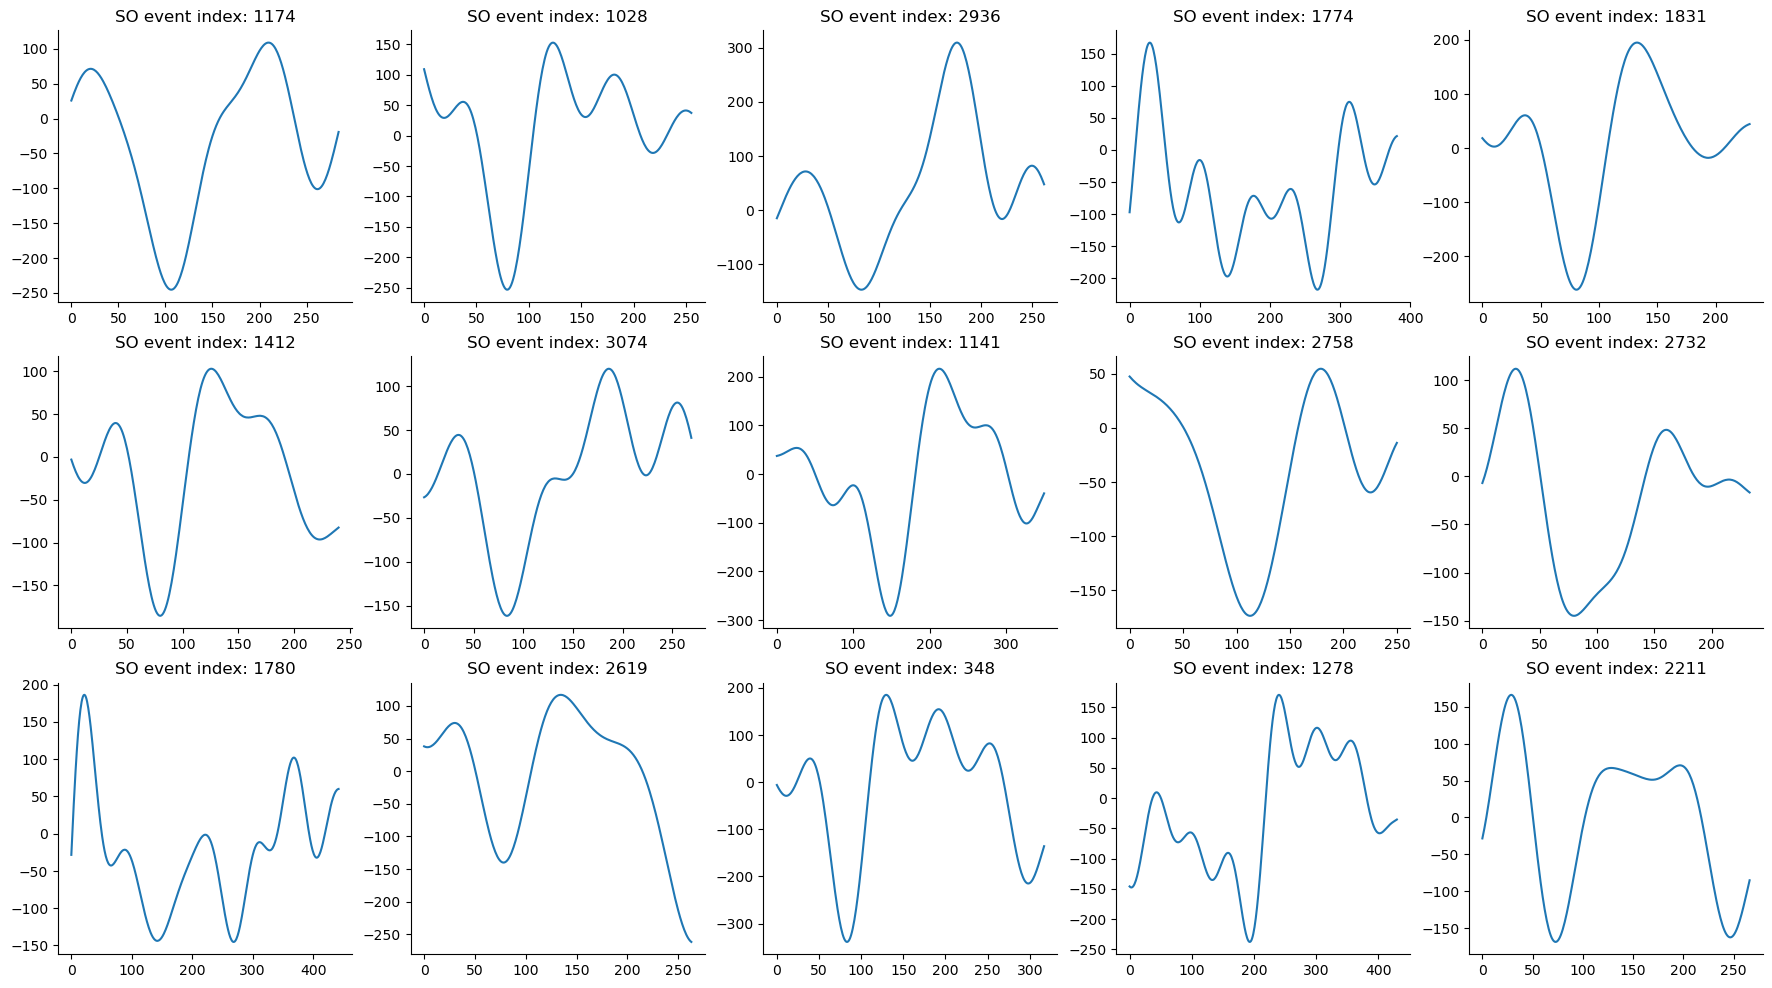

In [73]:
rng = np.random.default_rng()
so_inds = rng.choice(detected_so.index, size=15)
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(22, 12))
for ax, so_ind in zip(axs.ravel(), so_inds):
    tmp_so_trace = tmp_so_rec.time_slice(
        start_time=detected_so["down_crossing"].iloc[so_ind] - 0.2,
        end_time=detected_so["end_crossing"].iloc[so_ind] + 0.2,
    ).get_traces(channel_ids=["39"], return_in_uV=True)
    ax.plot(tmp_so_trace)
    ax.set_title(f"SO event index: {so_ind}")
    ax.spines[["top", "right"]].set_visible(False)

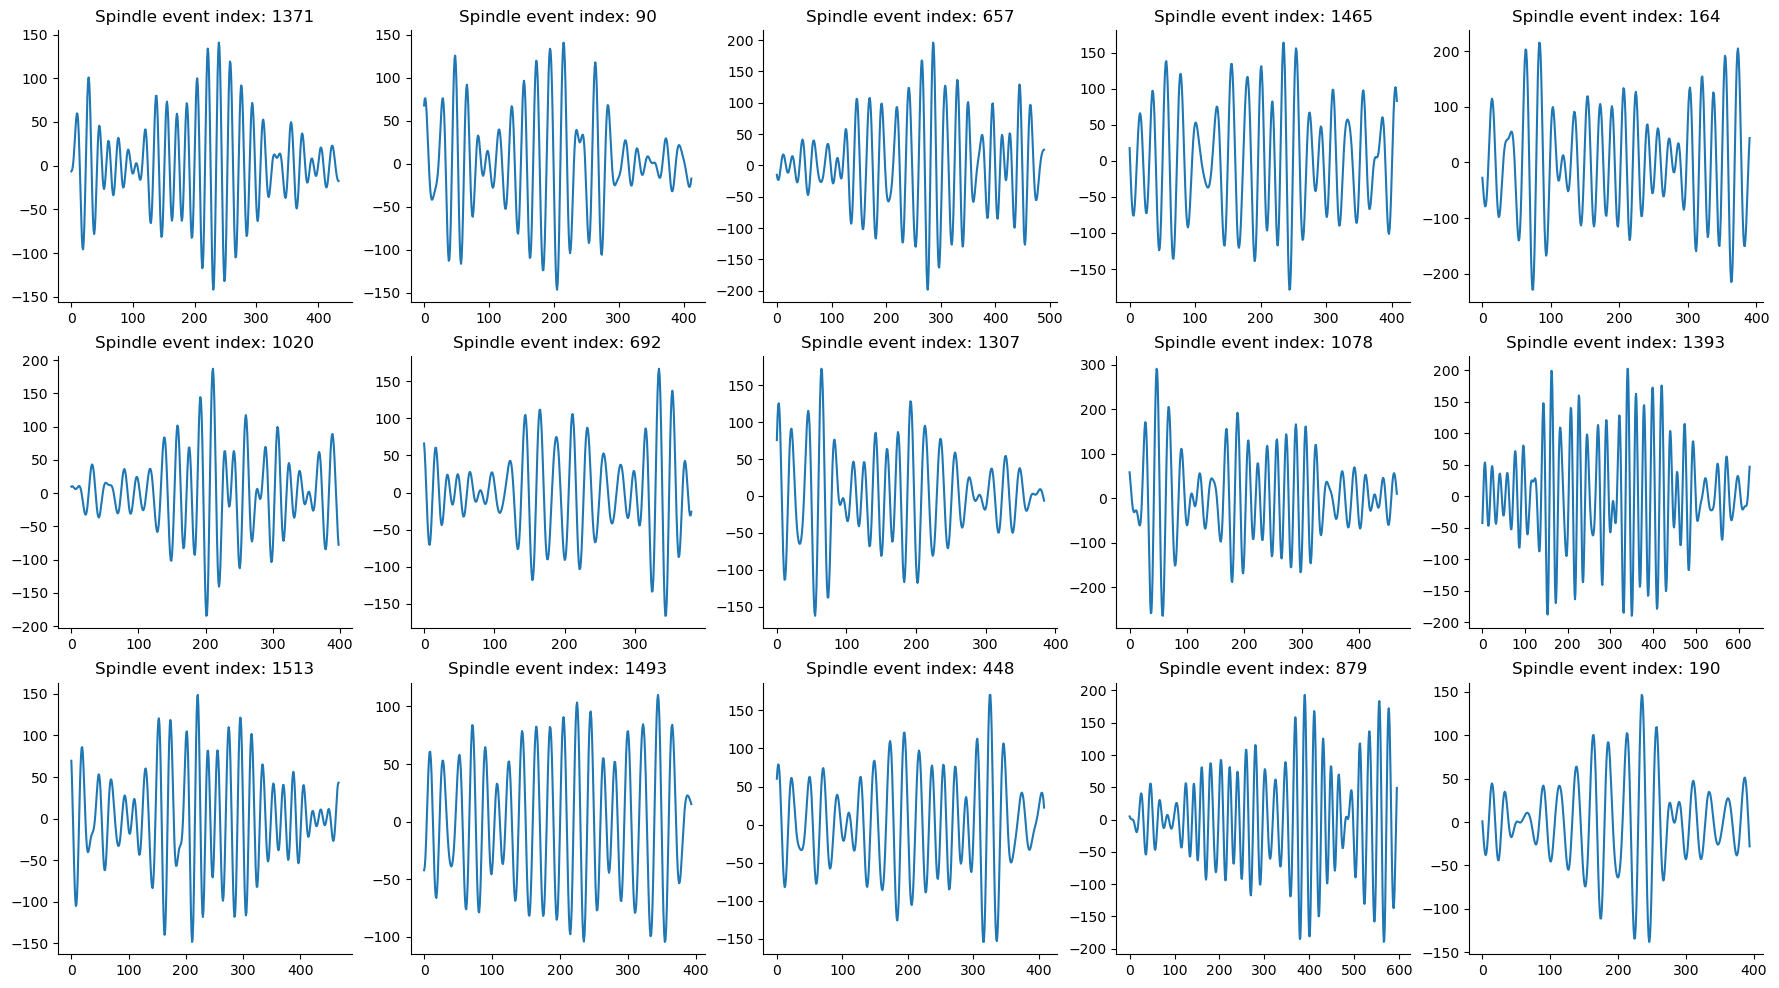

In [55]:
rng = np.random.default_rng()
spi_inds = rng.choice(detected_spi.index, size=15)
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(22, 12))
for ax, spi_ind in zip(axs.ravel(), spi_inds):
    tmp_spi_trace = tmp_spi_rec.time_slice(
        start_time=detected_spi["start"].iloc[spi_ind] - 0.5,
        end_time=detected_spi["end"].iloc[spi_ind] + 0.5,
    ).get_traces(channel_ids=["39"], return_in_uV=True)
    ax.plot(tmp_spi_trace)
    ax.set_title(f"Spindle event index: {spi_ind}")
    ax.spines[["top", "right"]].set_visible(False)

In [ ]:
## 267, 643, 657, 1393,

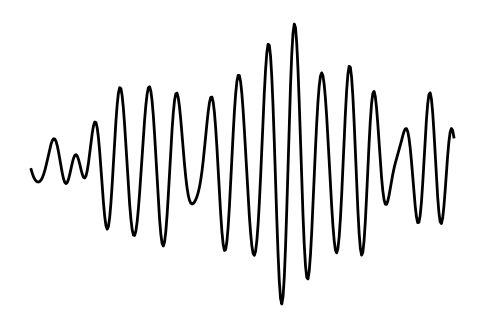

In [66]:
fig, ax = plt.subplots(figsize=(6, 4))
spi_ind = 657
tmp_spi_trace = tmp_spi_rec.time_slice(
    start_time=detected_spi["start"].iloc[spi_ind] - 0.2,
    end_time=detected_spi["end"].iloc[spi_ind] + 0.2,
).get_traces(channel_ids=["39"], return_in_uV=True)
ax.plot(tmp_spi_trace, c="k", lw=2)
# ax.set_title(f"Spindle event index: {spi_ind}")
ax.axis("off")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(
    Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures/ex_spi.svg"),
    bbox_inches="tight",
    dpi=400,
    facecolor="none",
    transparent=True,
)

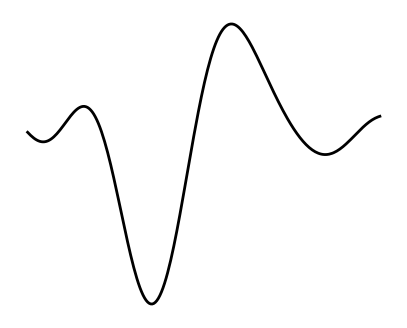

In [78]:
so_ind = 1831
fig, ax = plt.subplots(figsize=(5, 4))
tmp_so_trace = tmp_so_rec.time_slice(
    start_time=detected_so["down_crossing"].iloc[so_ind] - 0.2,
    end_time=detected_so["end_crossing"].iloc[so_ind] + 0.2,
).get_traces(channel_ids=["39"], return_in_uV=True)
ax.plot(tmp_so_trace, c="k", lw=2)
# ax.set_title(f"SO event index: {so_ind}")
ax.axis("off")
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(
    Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures/ex_so.svg"),
    bbox_inches="tight",
    dpi=400,
    facecolor="none",
    transparent=True,
)

In [ ]:
# For Rafa
tmp_eeg = load_rec(
    recording_path=full_path,
    probe=None,
    ret_eeg=True,
    ret_lfp=False,
    eeg_chs=["57", "39", "44", "54"],
    **{"stream_id": "0"},
)
tmp_emg = load_rec(
    recording_path=full_path,
    ret_lfp=False,
    ret_eeg=True,
    probe=None,
    eeg_chs=["41", "47"],
    **{"stream_id": "1"},
)
eeg_down_rec = sipp.resample(tmp_eeg, resample_rate=250)
emg_down_rec = sipp.resample(tmp_emg, resample_rate=250)
concat_traces = np.concatenate(
    [eeg_down_rec.get_traces(), emg_down_rec.get_traces()], axis=1
)
rec = si.NumpyRecording(
    concat_traces,
    sampling_frequency=eeg_down_rec.get_sampling_frequency(),
)
rec.set_times(eeg_down_rec.get_times())
rec.set_channel_offsets(
    np.concatenate(
        [eeg_down_rec.get_channel_offsets(), emg_down_rec.get_channel_offsets()]
    )
)
rec.set_channel_gains(
    np.concatenate([eeg_down_rec.get_channel_gains(), emg_down_rec.get_channel_gains()])
)
si.BinaryRecordingExtractor.write_recording(
    rec,
    file_paths=Path(save_path, f"{date}_eeg_emg_250.bin"),
    dtype="int16",
    **{
        "n_jobs": -1,
        "chunk_duration": 10.0,
        "progress_bar": True,
        "mp_context": "fork",
    },
)

In [5]:
tmp_eeg = load_rec(
    recording_path=full_path,
    probe=None,
    ret_eeg=True,
    ret_lfp=False,
    eeg_chs=["39", "37"],
    **{"stream_id": "0"},
)
tmp_emg = load_rec(
    recording_path=full_path,
    ret_lfp=False,
    ret_eeg=True,
    probe=None,
    eeg_chs=["41", "47"],
    **{"stream_id": "1"},
)
eeg_down_rec = sipp.resample(tmp_eeg, resample_rate=250)
emg_down_rec = sipp.resample(tmp_emg, resample_rate=250)
concat_traces = np.concatenate(
    [eeg_down_rec.get_traces(), emg_down_rec.get_traces()], axis=1
)
rec = si.NumpyRecording(
    concat_traces,
    sampling_frequency=eeg_down_rec.get_sampling_frequency(),
)
rec.set_times(eeg_down_rec.get_times())
rec.set_channel_offsets(
    np.concatenate(
        [eeg_down_rec.get_channel_offsets(), emg_down_rec.get_channel_offsets()]
    )
)
rec.set_channel_gains(
    np.concatenate([eeg_down_rec.get_channel_gains(), emg_down_rec.get_channel_gains()])
)
si.BinaryRecordingExtractor.write_recording(
    rec,
    file_paths=Path(save_path, f"{date}_eeg_emg_250.bin"),
    dtype="int16",
    **{
        "n_jobs": -1,
        "chunk_duration": 10.0,
        "progress_bar": True,
        "mp_context": "fork",
    },
)

/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/baserecording.py:496: UserWarning: Setting times with Recording.set_times() is not recommended because times are not always propagated across preprocessingUse this carefully!
  warnings.warn(


write_binary_recording (workers: 64 processes):   0%|          | 0/2162 [00:00<?, ?it/s]

In [ ]:
# if more than 1 session per day, concatenate them
eeg_rec = []
emg_rec = []
animal_path = Path(data_path, animal)
for sub_date in animal_path.glob(f"{date.split("_")[0]}*"):
    if sub_date.is_dir():
        print(sub_date.name)
        tmp_eeg = load_rec(
            recording_path=sub_date,
            probe=None,
            ret_eeg=True,
            ret_lfp=False,
            eeg_chs=["39", "37"],
            **{"stream_id": "0"},
        )
        tmp_emg = load_rec(
            recording_path=sub_date,
            ret_lfp=False,
            ret_eeg=True,
            probe=None,
            eeg_chs=["41", "47"],
            **{"stream_id": "1"},
        )
        print(tmp_eeg.get_duration())
        print(tmp_emg.get_duration())
        eeg_rec.append(tmp_eeg)
        emg_rec.append(tmp_emg)
eeg_rec = si.concatenate_recordings(eeg_rec)
emg_rec = si.concatenate_recordings(emg_rec)
eeg_down_rec = sipp.resample(eeg_rec, resample_rate=250)
emg_down_rec = sipp.resample(emg_rec, resample_rate=250)
concat_traces = np.concatenate(
    [eeg_down_rec.get_traces(), emg_down_rec.get_traces()], axis=1
)
rec = si.NumpyRecording(
    concat_traces,
    sampling_frequency=eeg_down_rec.get_sampling_frequency(),
)
rec.set_times(eeg_down_rec.get_times())
rec.set_channel_offsets(
    np.concatenate(
        [eeg_down_rec.get_channel_offsets(), emg_down_rec.get_channel_offsets()]
    )
)
rec.set_channel_gains(
    np.concatenate([eeg_down_rec.get_channel_gains(), emg_down_rec.get_channel_gains()])
)

2024-07-25_12-18-59
21604.544
21604.544
2024-07-25_05-55-34
22448.288
22448.288


/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/baserecording.py:496: UserWarning: Setting times with Recording.set_times() is not recommended because times are not always propagated across preprocessingUse this carefully!
  warnings.warn(


In [ ]:
si.BinaryRecordingExtractor.write_recording(
    rec,
    file_paths=Path(save_path, f"{date}_eeg_emg_250_full-1.bin"),
    dtype="int16",
    **{
        "n_jobs": -1,
        "chunk_duration": 10.0,
        "progress_bar": True,
        "mp_context": "fork",
    },
)

write_binary_recording (workers: 64 processes):   0%|          | 0/4406 [00:00<?, ?it/s]

In [ ]:
eeg_rec = []
emg_rec = []
animal_path = Path(data_path, animal)
for sub_date in animal_path.glob(f"{date.split("_")[0]}*"):
    if sub_date.is_dir():
        print(sub_date.name)
        tmp_eeg = load_rec(
            recording_path=sub_date,
            probe=None,
            ret_eeg=True,
            ret_lfp=False,
            eeg_chs=["39", "37"],
            **{"stream_id": "0"},
        )
        tmp_emg = load_rec(
            recording_path=sub_date,
            ret_lfp=False,
            ret_eeg=True,
            probe=None,
            eeg_chs=["41", "47"],
            **{"stream_id": "1"},
        )
        print(tmp_eeg.get_duration())
        print(tmp_emg.get_duration())
        eeg_rec.append(tmp_eeg)
        emg_rec.append(tmp_emg)
eeg_rec = si.concatenate_recordings(eeg_rec)
emg_rec = si.concatenate_recordings(emg_rec)
eeg_down_rec = sipp.resample(eeg_rec, resample_rate=250)
emg_down_rec = sipp.resample(emg_rec, resample_rate=250)
concat_traces = np.concatenate(
    [eeg_down_rec.get_traces(), emg_down_rec.get_traces()], axis=1
)
rec = si.NumpyRecording(
    concat_traces,
    sampling_frequency=eeg_down_rec.get_sampling_frequency(),
)
rec.set_times(eeg_down_rec.get_times())
rec.set_channel_offsets(
    np.concatenate(
        [eeg_down_rec.get_channel_offsets(), emg_down_rec.get_channel_offsets()]
    )
)
rec.set_channel_gains(
    np.concatenate([eeg_down_rec.get_channel_gains(), emg_down_rec.get_channel_gains()])
)
si.BinaryRecordingExtractor.write_recording(
    rec,
    file_paths=Path(save_path, f"{date}_eeg_emg_250_full.bin"),
    dtype="int16",
    **{
        "n_jobs": -1,
        "chunk_duration": 10.0,
        "progress_bar": True,
        "mp_context": "fork",
    },
)

2024-05-22_05-58-24
20364.784000000003
20364.784000000003
2024-05-22_16-15-46
7679.871999999999
7679.871999999999
2024-05-22_11-53-25
15572.784
15572.784


/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/baserecording.py:496: UserWarning: Setting times with Recording.set_times() is not recommended because times are not always propagated across preprocessingUse this carefully!
  warnings.warn(


write_binary_recording (workers: 64 processes):   0%|          | 0/4362 [00:00<?, ?it/s]